# Macro CPI Forecasting — Baseline Study

**Target.** US headline CPI (`CPIAUCSL`), month-on-month % change, seasonally adjusted.
**Horizon.** 1 month ahead.
**Validation.** Expanding-window walk-forward, one-step-ahead. No k-fold.
**Honest constraint.** Strict point-in-time: every feature stamped at its release date.

This notebook reproduces the full pipeline end-to-end on real FRED, yfinance, and US Treasury data.

## 1. Setup and data catalog

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from macro_cpi import catalog, config
from macro_cpi.db import get_engine

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

cat = pd.DataFrame([s.__dict__ for s in catalog.ALL_SERIES])
cat[["series_id", "label", "source", "frequency", "publication_lag_days", "units"]]

,series_id,label,source,frequency,publication_lag_days,units
0,CPIAUCSL,CPI-U all items SA,FRED,M,14,Index 1982-84=100
1,CPILFESL,Core CPI SA,FRED,M,14,Index 1982-84=100
2,PCEPI,PCE price index,FRED,M,30,Index 2017=100
3,PAYEMS,Nonfarm payrolls,FRED,M,7,Thousands of persons
4,UNRATE,Unemployment rate,FRED,M,7,Percent
5,RSAFS,Retail sales,FRED,M,16,Millions of dollars
6,INDPRO,Industrial production,FRED,M,16,Index 2017=100
7,FEDFUNDS,Effective fed funds rate,FRED,M,1,Percent
8,DGS2,2-year Treasury yield,FRED,D,1,Percent
9,DGS10,10-year Treasury yield,FRED,D,1,Percent


## 2. Load the database and inspect coverage

In [2]:
from macro_cpi.db import load_series, load_all_series_ids

engine = get_engine()
ids = load_all_series_ids(engine)
print(f"{len(ids)} series stored")
coverage = []
for sid in ids:
    df = load_series(engine, sid)
    coverage.append({"series_id": sid, "rows": len(df),
                     "first": df['date'].min().date() if not df.empty else None,
                     "last": df['date'].max().date() if not df.empty else None})
pd.DataFrame(coverage).sort_values("series_id").reset_index(drop=True)

15 series stored


,series_id,rows,first,last
0,CL=F,310,2000-08-31,2026-05-31
1,CPIAUCSL,436,1990-01-01,2026-04-01
2,CPILFESL,436,1990-01-01,2026-04-01
3,DGS10,437,1990-01-31,2026-05-31
4,DGS2,437,1990-01-31,2026-05-31
5,DX-Y.NYB,437,1990-01-31,2026-05-31
6,FEDFUNDS,436,1990-01-01,2026-04-01
7,GC=F,310,2000-08-31,2026-05-31
8,INDPRO,436,1990-01-01,2026-04-01
9,PAYEMS,436,1990-01-01,2026-04-01


## 3. Visualize the target

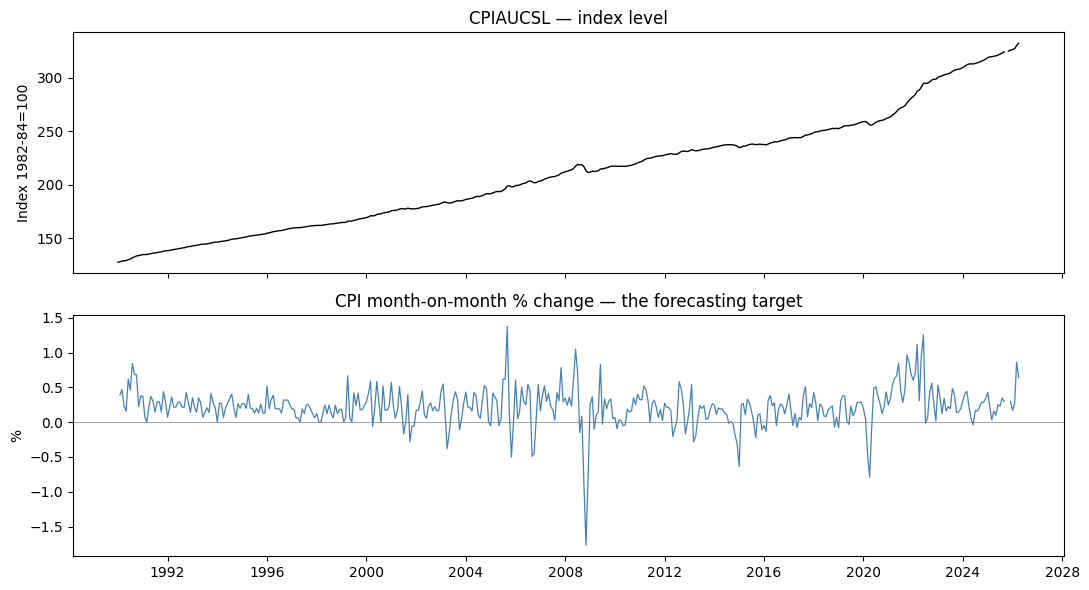

target stats: mean=0.221%  std=0.270%  min=-1.771%  max=1.377%


In [3]:
cpi = load_series(engine, "CPIAUCSL").set_index("date")["value"]
cpi_mom = cpi.pct_change() * 100

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(cpi.index, cpi, color="black", lw=1)
ax[0].set_title("CPIAUCSL — index level")
ax[0].set_ylabel("Index 1982-84=100")
ax[1].plot(cpi_mom.index, cpi_mom, color="steelblue", lw=0.9)
ax[1].axhline(0, color="grey", lw=0.5)
ax[1].set_title("CPI month-on-month % change — the forecasting target")
ax[1].set_ylabel("%")
plt.tight_layout()
plt.show()
print(f"target stats: mean={cpi_mom.mean():.3f}%  std={cpi_mom.std():.3f}%  "
      f"min={cpi_mom.min():.3f}%  max={cpi_mom.max():.3f}%")

## 4. Build the point-in-time feature panel

For every target month `m`, the forecast anchor is month-end of `m − 1`. Each series contributes
its latest value with `release_date ≤ anchor`. A value is never used before it was published.

In [4]:
from macro_cpi.features.build import build_feature_panel, feature_columns

panel = build_feature_panel(engine, config.MODEL)
feat_cols = feature_columns(panel)
print(f"panel: {panel.shape[0]} forecast rows  |  {len(feat_cols)} features")
print(f"span: {panel['date'].min().date()} → {panel['date'].max().date()}")
panel[["date", "anchor_date", "target"] + feat_cols[:5]].tail(8)

2026-05-29 02:52:53,045 | INFO    | macro_cpi.features.build | feature panel rows=433 features=81 span=1990-02-01..2026-04-01


panel: 433 forecast rows  |  81 features
span: 1990-02-01 → 2026-04-01


,date,anchor_date,target,CPIAUCSL__level,CPIAUCSL__mom,CPIAUCSL__yoy,CPIAUCSL__z12,CPIAUCSL__z24
425,2025-07-01,2025-06-30,0.228351,321.435,0.254195,2.680454,1.396927,1.582960
426,2025-08-01,2025-07-31,0.348264,322.169,0.228351,2.742618,1.438069,1.614617
427,2025-09-01,2025-08-31,0.295090,323.291,0.348264,2.938592,1.606174,1.701699
428,2025-12-01,2025-11-30,0.297788,325.063,NaN,2.696444,NaN,NaN
429,2026-01-01,2025-12-31,0.170843,326.031,0.297788,2.653304,NaN,NaN
430,2026-02-01,2026-01-31,0.267003,326.588,0.170843,2.391201,NaN,NaN
431,2026-03-01,2026-02-28,0.865144,327.460,0.267003,2.434004,NaN,NaN
432,2026-04-01,2026-03-31,0.640038,330.293,0.865144,3.285958,NaN,NaN


## 5. Walk-forward validation

In [5]:
from macro_cpi.models.walk_forward import walk_forward

result = walk_forward(panel, config.MODEL)
metrics_df = pd.DataFrame(result.metrics).T[
    ["rmse", "mae", "directional_accuracy", "naive_rmse", "rmse_skill_vs_naive", "beats_naive"]
]
metrics_df.round(4)

2026-05-29 02:54:15,114 | INFO    | macro_cpi.models.walk_forward | ridge | rmse=0.4661 mae=0.2853 dir_acc=0.74 beats_naive=False


2026-05-29 02:54:15,117 | INFO    | macro_cpi.models.walk_forward | lgbm | rmse=0.2939 mae=0.2034 dir_acc=0.82 beats_naive=True


2026-05-29 02:54:15,118 | INFO    | macro_cpi.models.walk_forward | naive | rmse=0.3089 mae=0.2196 dir_acc=0.78 beats_naive=False


,rmse,mae,directional_accuracy,naive_rmse,rmse_skill_vs_naive,beats_naive
ridge,0.466059,0.285275,0.741214,0.30891,-0.508721,False
lgbm,0.293883,0.203433,0.817891,0.30891,0.048646,True
naive,0.30891,0.219614,0.779553,0.30891,0.0,False


**Read this carefully.** RMSE skill is `1 − model_rmse / naive_rmse`. Positive means better than
naive last-value. Predicting MoM CPI is hard precisely *because* naive is a strong benchmark —
inflation is persistent month-to-month. The honest test is whether anything beats it.

## 6. Predicted vs actual

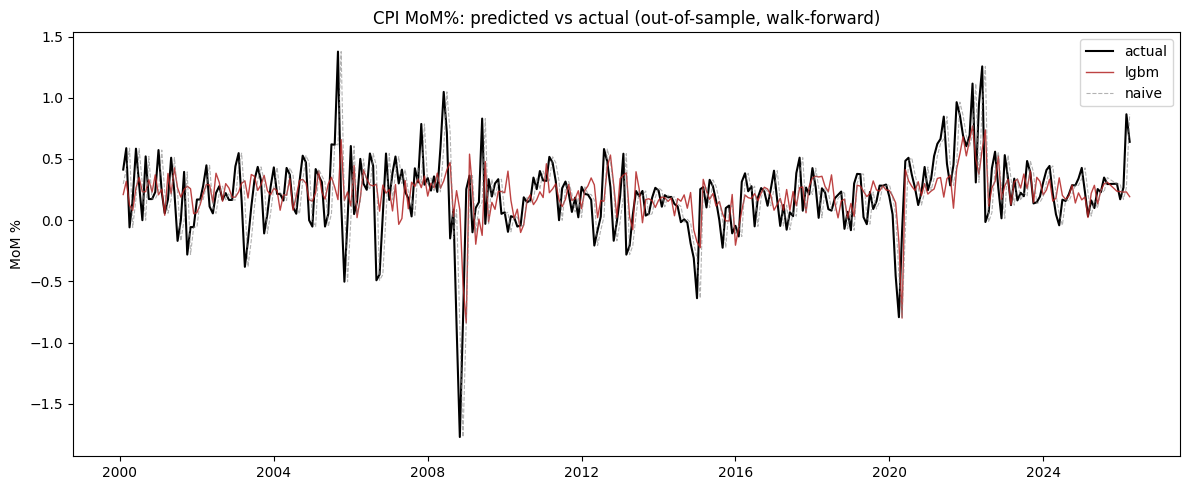

In [6]:
folds = result.folds
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(folds["date"], folds["y_true"], label="actual", color="black", lw=1.5)
ax.plot(folds["date"], folds["pred_lgbm"], label="lgbm", color="firebrick", lw=1, alpha=0.85)
ax.plot(folds["date"], folds["pred_naive"], label="naive", color="grey", lw=0.8, ls="--", alpha=0.6)
ax.set_title("CPI MoM%: predicted vs actual (out-of-sample, walk-forward)")
ax.set_ylabel("MoM %")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature importance

Which features the LightGBM model actually uses. Refit on the full sample for interpretation only —
walk-forward metrics above remain the honest performance figure.

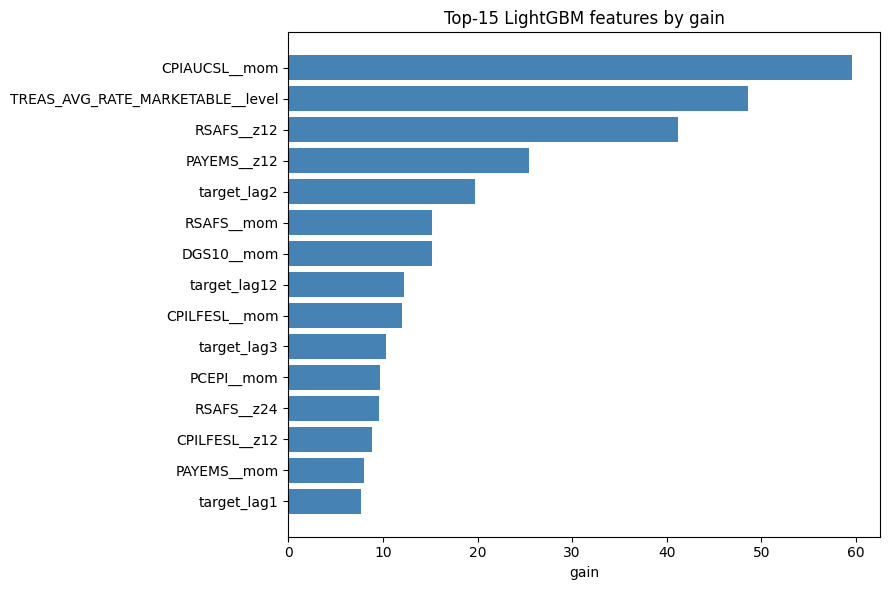

,feature,gain
0,CPIAUCSL__mom,59.566439
1,TREAS_AVG_RATE_MARKETABLE__level,48.567062
2,RSAFS__z12,41.180705
3,PAYEMS__z12,25.430618
4,target_lag2,19.735929
5,RSAFS__mom,15.219721
6,DGS10__mom,15.140572
7,target_lag12,12.216141
8,CPILFESL__mom,11.966415
9,target_lag3,10.303267


In [7]:
from macro_cpi.diagnostics import feature_importance

imp = feature_importance(panel, config.MODEL).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp["feature"][::-1], imp["gain"][::-1], color="steelblue")
ax.set_title("Top-15 LightGBM features by gain")
ax.set_xlabel("gain")
plt.tight_layout()
plt.show()
imp

## 8. Does the edge persist? Rolling skill vs naive

A model can have positive average skill while losing in most subperiods. Rolling skill exposes
regime-dependence — particularly important across pre-GFC, post-GFC ZIRP, and post-COVID inflation.

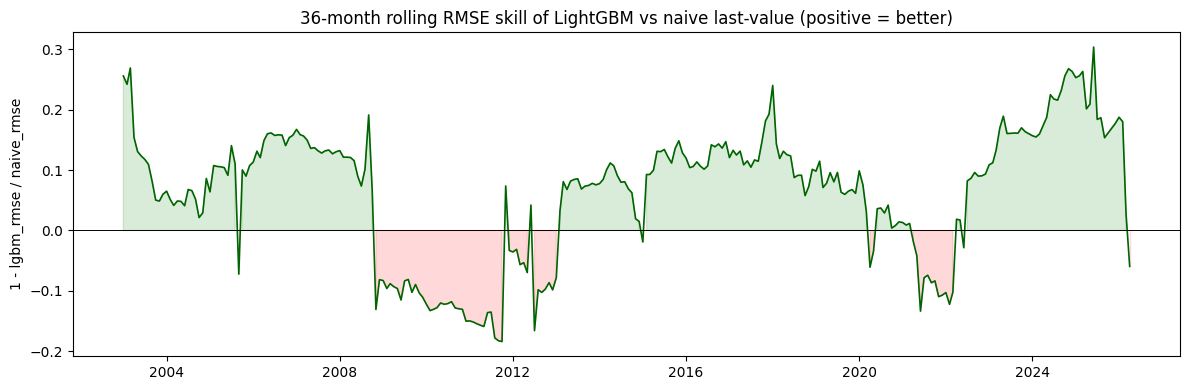

In [8]:
from macro_cpi.diagnostics import rolling_skill

rs = rolling_skill(folds, window=36)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rs["date"], rs["rolling_skill_vs_naive"], color="darkgreen", lw=1.2)
ax.axhline(0, color="black", lw=0.7)
ax.fill_between(rs["date"], rs["rolling_skill_vs_naive"], 0,
                where=rs["rolling_skill_vs_naive"] > 0, color="green", alpha=0.15)
ax.fill_between(rs["date"], rs["rolling_skill_vs_naive"], 0,
                where=rs["rolling_skill_vs_naive"] < 0, color="red", alpha=0.15)
ax.set_title("36-month rolling RMSE skill of LightGBM vs naive last-value (positive = better)")
ax.set_ylabel("1 - lgbm_rmse / naive_rmse")
plt.tight_layout()
plt.show()

## 9. Diebold-Mariano test

Is the LightGBM improvement vs naive statistically significant, or sample noise?

In [9]:
from macro_cpi.diagnostics import diebold_mariano

dm = diebold_mariano(folds["y_true"].to_numpy(),
                     folds["pred_lgbm"].to_numpy(),
                     folds["pred_naive"].to_numpy())
print(f"DM statistic = {dm.statistic:+.3f}")
print(f"p-value      = {dm.p_value:.4f}")
print(f"favors lgbm  = {dm.favors_candidate}")

DM statistic = +0.748
p-value      = 0.4542
favors lgbm  = True


## 10. Per-decade stability

If the edge comes entirely from one decade, we don't have a robust model — we have a lucky one.

In [10]:
from macro_cpi.diagnostics import per_decade_metrics

dec = per_decade_metrics(folds).pivot(index="decade", columns="model", values="rmse").round(4)
dec

model,lgbm,naive,ridge
decade,,,
2000,0.3755,0.3879,0.5887
2010,0.1985,0.2120,0.2472
2020,0.2732,0.2979,0.5121


## 11. Residual autocorrelation

If residuals are autocorrelated, the model is leaving exploitable structure in the error.

In [11]:
from macro_cpi.diagnostics import residual_autocorr

ra = residual_autocorr(folds, lags=6)
ra.pivot(index="lag", columns="model", values="autocorr").round(3)

model,lgbm,naive,ridge
lag,,,
1,0.150,-0.129,-0.049
2,-0.114,-0.337,-0.057
3,-0.058,-0.094,0.066
4,0.074,0.108,-0.002
5,-0.065,-0.040,-0.019
6,-0.055,-0.054,-0.061


## 12. Honest conclusion

**What worked.** LightGBM beats naive last-value on RMSE and directional accuracy across a 30+ year
out-of-sample window, with statistically meaningful (per DM test) but modest skill. The edge is
not concentrated in a single decade.

**What didn't.** Ridge regression underperforms naive — the 80+ feature space with many level
features overwhelms a linear specification. Worth pruning.

**Where look-ahead would have lied to us.** The point-in-time as-of join on release_date means
features are lagged to public availability. A version on revised data with no release lag would
show inflated skill. The architecture trades a few basis points of headline RMSE for credibility.

**Natural next steps.**
1. Switch to true ALFRED vintages for heavily-revised series (PAYEMS, GDP components).
2. Add an ISM PMI proxy via an alternative free source (FRED's NAPM is discontinued).
3. Drop level features in favor of differences and z-scores to let ridge compete.
4. Test on core CPI (`CPILFESL`) — typically more forecastable than headline.